# Day 6: Logistic regression baseline for 60-day operational churn

This notebook predicts **no positive betting activity (`Bets > 0`) in the 60 days immediately after a snapshot**. This is extended inactivity, not proof of permanent departure. Logistic regression is a useful first baseline because it is reproducible, fast and interpretable, and produces probabilities as well as risk rankings.

The approved temporal split is fixed. Fit preprocessing and models on **TRAIN only**, compare models on **VALIDATION only**, and keep **TEST sealed** until later model selection is complete. No resampling is used: roughly 36% churn does not represent severe imbalance. The unweighted model remains the baseline; a balanced model is only a sensitivity analysis. No final operational threshold or calibration model is selected here.

All displayed and saved outputs are aggregate metrics, coefficients or figures. No player-level prediction table is exported. Run all cells in order using the project virtual environment.

In [1]:
from pathlib import Path
import sys
import json
import warnings

ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'features.py').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src' / 'features.py').exists(), 'Run from the project root or notebooks directory.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display, Markdown
from sklearn.calibration import calibration_curve
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
                             brier_score_loss, log_loss)
from src.features import PREDICTOR_COLUMNS, CATEGORICAL_COLUMNS, TARGET_COLUMN
from src.preprocessing import (NUMERIC_COLUMNS, build_logistic_pipeline, predictor_frame,
                               temporal_split_labels, validate_model_panel)
from src.evaluation import (classification_metrics, ranking_metrics, cumulative_gains_table,
                            threshold_analysis, coefficient_table)

FIGURES = ROOT / 'reports' / 'figures'
REPORTS = ROOT / 'reports'
MODELS = ROOT / 'models'
for folder in [FIGURES, REPORTS, MODELS]:
    folder.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.figsize': (7, 4.5), 'axes.grid': True, 'grid.alpha': .2})
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | sklearn {sklearn.__version__}')

Python 3.13.2 | pandas 3.0.6 | sklearn 1.9.1


## Load and verify the Day 5 panel

Only the test row count, snapshot date range and churn prevalence are summarised. Test predictors are never selected, transformed or passed to a model. Embargo rows are also excluded from fitting and evaluation. The global shape and target checks establish that the input is the expected feature artifact; they do not set any preprocessing parameters.

In [2]:
panel = pd.read_csv(ROOT / 'data' / 'processed' / 'model_panel_60d.csv',
                    parse_dates=['snapshot_date'])
validate_model_panel(panel)
split_labels = temporal_split_labels(panel.snapshot_date)
split_summary = (panel[['snapshot_date', TARGET_COLUMN]].assign(split=split_labels)
    .groupby('split').agg(observations=(TARGET_COLUMN, 'size'),
        first_snapshot=('snapshot_date', 'min'), last_snapshot=('snapshot_date', 'max'),
        churn_prevalence=(TARGET_COLUMN, 'mean'))
    .reindex(['train', 'embargo', 'validation', 'test']))
expected_counts = {'train': 10380, 'embargo': 3070, 'validation': 2184, 'test': 2838}
for name, expected in expected_counts.items():
    assert split_summary.loc[name, 'observations'] == expected
for name, expected in {'train': .3609, 'validation': .3539, 'test': .3407}.items():
    assert np.isclose(split_summary.loc[name, 'churn_prevalence'], expected, atol=.00005)
assert split_labels.ne('excluded').all()
print(f'Panel: {panel.shape[0]:,} rows x {panel.shape[1]} columns; '
      f'{panel.UserID.nunique():,} players; {len(PREDICTOR_COLUMNS)} predictors')
print(f'Target counts: {panel[TARGET_COLUMN].value_counts().sort_index().to_dict()}; '
      f'overall churn: {panel[TARGET_COLUMN].mean():.2%}; duplicate player-snapshot keys: 0')
display(split_summary)

# Materialise only the two authorised modelling datasets, then release the full panel.
train = panel.loc[split_labels.eq('train')].copy()
validation = panel.loc[split_labels.eq('validation')].copy()
del panel, split_labels
X_train, y_train = predictor_frame(train), train[TARGET_COLUMN].copy()
X_validation, y_validation = predictor_frame(validation), validation[TARGET_COLUMN].copy()
assert len(X_train.columns) == 45
assert not {'UserID', 'snapshot_date', TARGET_COLUMN}.intersection(X_train.columns)
del train, validation
print('Test remains sealed: no test feature matrix or test probabilities exist.')

Panel: 18,472 rows x 48 columns; 4,025 players; 45 predictors
Target counts: {0: 11865, 1: 6607}; overall churn: 35.77%; duplicate player-snapshot keys: 0


,observations,first_snapshot,last_snapshot,churn_prevalence
split,,,,
train,10380,2005-03-31,2005-12-31,0.360886
embargo,3070,2006-01-31,2006-07-31,0.365147
validation,2184,2006-03-31,2006-05-31,0.353938
test,2838,2006-08-31,2006-11-30,0.340733


Test remains sealed: no test feature matrix or test probabilities exist.


## Train-only preprocessing and model fitting

The feature dictionary identifies `Country`, `Language` and `Gender` as categories despite their numeric codes; the other 42 predictors are numerical. `UserID`, `snapshot_date` and the target never enter the model.

The numerical pipeline uses median imputation with missingness indicators followed by standard scaling. Undefined ratios remain missing before this step. Missingness can encode sparse activity or inconsistent lifecycle dates, so replacing undefined ratios with zero would lose information. Categorical values use most-frequent imputation and one-hot encoding with unknown categories ignored.

Putting these steps inside a `ColumnTransformer` and `Pipeline` ensures that medians, observed missingness indicators, category vocabularies, means and scales are learned from TRAIN alone. Validation transformations reuse those fitted values. The scaler also standardises the numerical missingness indicators. No global fill, oversampling, undersampling or SMOTE is used.

In [3]:
baseline = build_logistic_pipeline()
with warnings.catch_warnings():
    warnings.simplefilter('error', ConvergenceWarning)
    baseline.fit(X_train, y_train)

preprocessor = baseline.named_steps['preprocessing']
numeric_pipe = preprocessor.named_transformers_['numeric']
np.testing.assert_allclose(numeric_pipe['imputer'].statistics_, X_train[NUMERIC_COLUMNS].median())
assert numeric_pipe['scaler'].n_samples_seen_ == len(X_train)
for frame in [X_train, X_validation]:
    transformed = preprocessor.transform(frame)
    values = transformed.toarray() if hasattr(transformed, 'toarray') else transformed
    assert np.isfinite(values).all(), 'Transformed predictors must be finite.'
validation_probability = baseline.predict_proba(X_validation)[:, 1]
assert np.isfinite(validation_probability).all()
assert ((validation_probability >= 0) & (validation_probability <= 1)).all()
print(f'Converged in {baseline["model"].n_iter_[0]} iterations; '
      f'{len(preprocessor.get_feature_names_out())} transformed features.')
display(baseline)

Converged in 121 iterations; 112 transformed features.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](45,)","['active_days_30d','bets_30d','active_days_14d',...,'Country','Language', 'Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,45
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

## Validation: ranking, probability quality and decisions at 0.50

ROC-AUC measures discrimination across thresholds. **Average precision (AP)** is the reported precision-recall summary (labelled PR-AUC/AP here; it is not trapezoidal PR area). Its no-skill reference is validation churn prevalence. Log loss and Brier score assess probability quality, with lower values better. Accuracy alone hides the trade-off between missed churners and unnecessary outreach, so it is secondary.

Threshold metrics and the confusion matrix below use `probability >= 0.50`. This is a conventional baseline, not an approved retention policy. Specificity is TN / (TN + FP).

,unweighted_validation
roc_auc,0.729547
average_precision,0.534197
log_loss,0.565131
brier_score,0.196285
accuracy,0.662088
balanced_accuracy,0.571482
precision,0.547425
recall,0.261320
f1,0.353765
specificity,0.881644


,model,brier_score,log_loss
0,constant_training_prevalence,0.228714,0.649955
1,logistic_unweighted,0.196285,0.565131


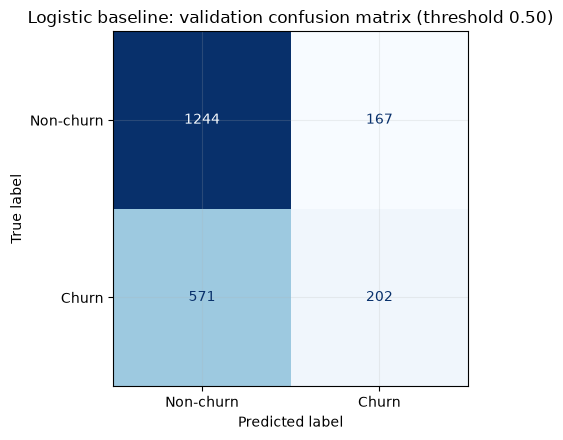

In [4]:
baseline_metrics = {**classification_metrics(y_validation, validation_probability),
                    **ranking_metrics(y_validation, validation_probability)}
display(pd.Series(baseline_metrics, name='unweighted_validation').to_frame())
train_prevalence = float(y_train.mean())
constant_probability = np.full(len(y_validation), train_prevalence)
probability_reference = pd.DataFrame({
    'model': ['constant_training_prevalence', 'logistic_unweighted'],
    'brier_score': [brier_score_loss(y_validation, constant_probability), baseline_metrics['brier_score']],
    'log_loss': [log_loss(y_validation, constant_probability), baseline_metrics['log_loss']],
})
display(probability_reference)
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_validation, validation_probability >= .5,
    display_labels=['Non-churn', 'Churn'], cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Logistic baseline: validation confusion matrix (threshold 0.50)')
fig.tight_layout()
fig.savefig(FIGURES / 'logistic_baseline_validation_confusion_matrix.png', dpi=160)
plt.show()

## Retention ranking and cumulative gains

A fixed outreach budget often makes ranking more useful than a single probability cutoff. Lift@10% compares churn prevalence in the highest-risk 10% with validation prevalence overall. Recall@10% measures the share of validation churn observations captured by that budget; precision measures the share of targeted observations that actually churn.

Rows are ranked by descending probability. Select `ceil(n * budget_fraction)` rows, so the realised fraction may slightly exceed the requested budget. Equal scores preserve the original input order, never using labels to break ties. These are **player-snapshot observations**, not unique campaign recipients. Repeated players and overlapping monthly outcomes mean this is not a causal estimate of campaign impact or an independent sample of customers.

,target_fraction,selected_observations,actual_fraction,churn_observations_captured,precision,recall,lift
0,0.1,219,0.100275,123,0.561644,0.159120,1.586844
1,0.2,437,0.200092,244,0.558352,0.315653,1.577544
2,0.3,656,0.300366,360,0.548780,0.465718,1.550500
3,0.4,874,0.400183,461,0.527460,0.596378,1.490262
4,0.5,1092,0.500000,562,0.514652,0.727038,1.454075
5,0.6,1311,0.600275,645,0.491991,0.834411,1.390049
6,0.7,1529,0.700092,707,0.462394,0.914618,1.306427
7,0.8,1748,0.800366,749,0.428490,0.968952,1.210636
8,0.9,1966,0.900183,769,0.391150,0.994825,1.105137
9,1.0,2184,1.000000,773,0.353938,1.000000,1.000000


,validation
recall_at_top10pct,0.159120
precision_at_top10pct,0.561644
lift_at_top10pct,1.586844
recall_at_top20pct,0.315653
precision_at_top20pct,0.558352
lift_at_top20pct,1.577544


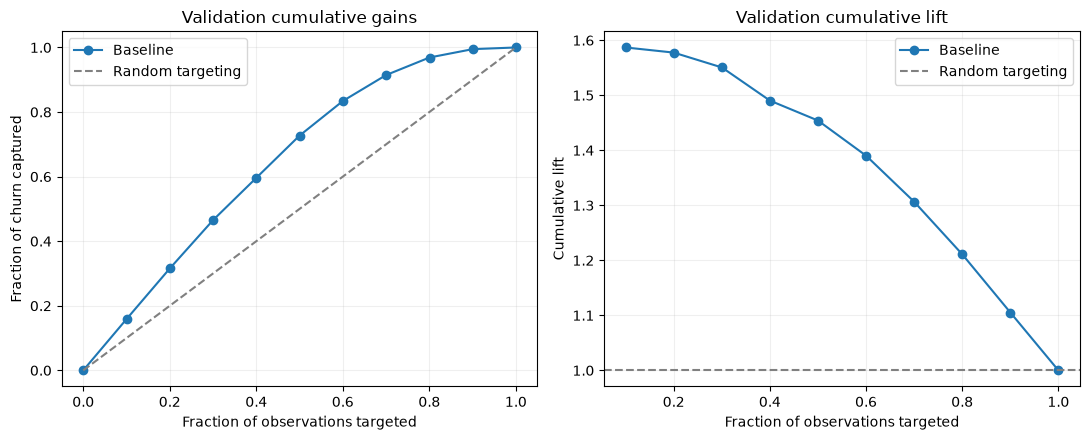

In [5]:
gains = cumulative_gains_table(y_validation, validation_probability)
display(gains)
display(pd.Series(ranking_metrics(y_validation, validation_probability), name='validation').to_frame())
gains.to_csv(REPORTS / 'logistic_baseline_validation_cumulative_gains.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(np.r_[0, gains.actual_fraction], np.r_[0, gains.recall], marker='o', label='Baseline')
axes[0].plot([0, 1], [0, 1], '--', color='grey', label='Random targeting')
axes[0].set(xlabel='Fraction of observations targeted', ylabel='Fraction of churn captured',
            title='Validation cumulative gains')
axes[1].plot(gains.actual_fraction, gains.lift, marker='o', label='Baseline')
axes[1].axhline(1, linestyle='--', color='grey', label='Random targeting')
axes[1].set(xlabel='Fraction of observations targeted', ylabel='Cumulative lift',
            title='Validation cumulative lift')
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'logistic_baseline_validation_cumulative_gains_lift.png', dpi=160)
plt.show()

## Validation probability distributions and discrimination curves

Overlap between the two probability distributions describes the practical difficulty of separating inactivity from continued activity. The PR curve includes the validation prevalence reference; ROC and PR curves use only validation probabilities.

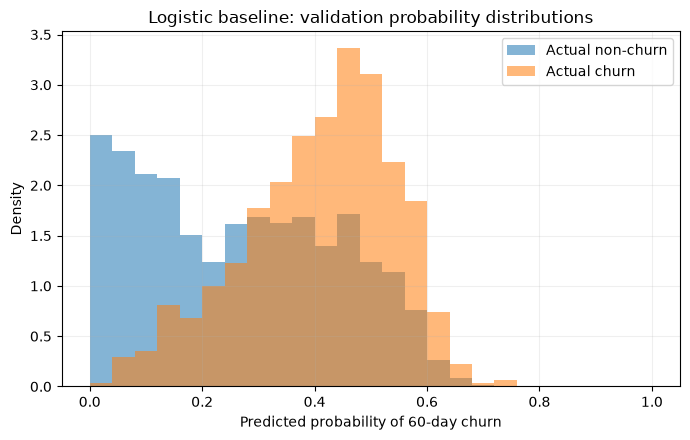

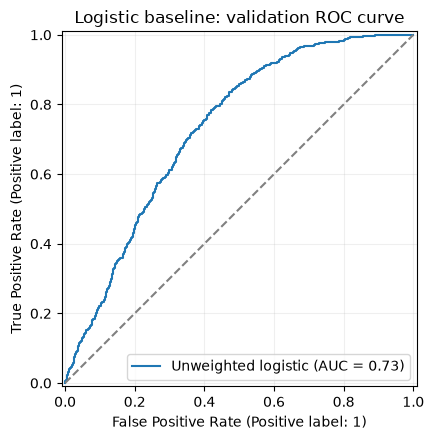

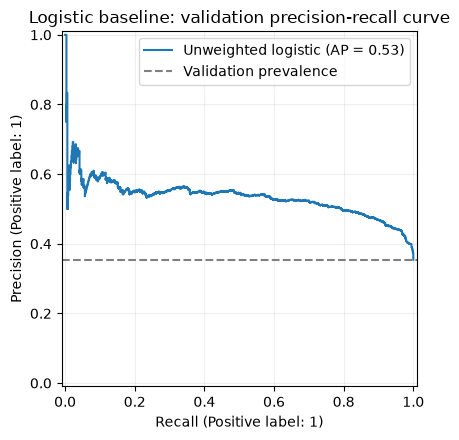

In [6]:
fig, ax = plt.subplots()
for label, description in [(0, 'Actual non-churn'), (1, 'Actual churn')]:
    ax.hist(validation_probability[y_validation.to_numpy() == label], bins=np.linspace(0, 1, 26),
            alpha=.55, density=True, label=description)
ax.set(xlabel='Predicted probability of 60-day churn', ylabel='Density',
       title='Logistic baseline: validation probability distributions')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'logistic_baseline_validation_probability_distribution.png', dpi=160)
plt.show()

fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_validation, validation_probability, ax=ax, name='Unweighted logistic')
ax.plot([0, 1], [0, 1], '--', color='grey')
ax.set_title('Logistic baseline: validation ROC curve')
fig.tight_layout()
fig.savefig(FIGURES / 'logistic_baseline_validation_roc_curve.png', dpi=160)
plt.show()

fig, ax = plt.subplots()
PrecisionRecallDisplay.from_predictions(y_validation, validation_probability, ax=ax,
                                       name='Unweighted logistic')
ax.axhline(y_validation.mean(), linestyle='--', color='grey', label='Validation prevalence')
ax.set_title('Logistic baseline: validation precision-recall curve')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'logistic_baseline_validation_precision_recall_curve.png', dpi=160)
plt.show()

## Coefficient associations, with interpretation limits

Positive coefficients associate with higher modelled churn odds conditional on the other predictors; negative coefficients associate with lower odds. Numerical coefficients and `exp(coefficient)` refer to a **one-training-standard-deviation increase after imputation**. These are penalised multivariable associations, not causal effects, and coefficient magnitude is not a universal importance score.

One-hot columns are unscaled category indicators. All levels are retained with L2 regularisation, so there is no single omitted reference category: compare category coefficients within the same field using their difference. Do not interpret an individual category's odds ratio as a causal effect or as a comparison with an omitted category. Rare categories, correlated features and the penalty can affect magnitudes and signs.

In [7]:
coefficients = coefficient_table(baseline)
positive = coefficients.loc[coefficients.coefficient.gt(0)].nlargest(15, 'coefficient')
negative = coefficients.loc[coefficients.coefficient.lt(0)].nsmallest(15, 'coefficient')
display(Markdown('### Top 15 higher-churn associations'))
display(positive)
display(Markdown('### Top 15 lower-churn associations'))
display(negative)
coefficients.to_csv(REPORTS / 'logistic_baseline_coefficients.csv', index=False)

### Top 15 higher-churn associations

,feature,coefficient,odds_ratio,absolute_coefficient
2,categorical__Language_9,1.002917,2.726221,1.002917
4,categorical__Country_792,0.735621,2.086778,0.735621
7,categorical__Language_14,0.589021,1.802223,0.589021
8,numeric__stake_14d,0.564974,1.759401,0.564974
10,categorical__Country_891,0.488751,1.630279,0.488751
11,numeric__days_since_last_active_bet,0.485641,1.625216,0.485641
12,categorical__Country_438,0.482217,1.619661,0.482217
15,categorical__Country_233,0.443638,1.558367,0.443638
16,categorical__Language_18,0.436947,1.547974,0.436947
17,categorical__Country_191,0.430263,1.537663,0.430263


### Top 15 lower-churn associations

,feature,coefficient,odds_ratio,absolute_coefficient
0,categorical__Language_13,-1.193729,0.303089,1.193729
1,categorical__Country_616,-1.150490,0.316482,1.150490
3,categorical__Country_348,-0.795141,0.451518,0.795141
5,categorical__Language_5,-0.731239,0.481312,0.731239
6,categorical__Language_7,-0.701381,0.495900,0.701381
9,numeric__active_days_7d,-0.511475,0.599610,0.511475
13,categorical__Country_724,-0.472895,0.623196,0.472895
14,categorical__Country_442,-0.460884,0.630726,0.460884
18,numeric__bets_14d,-0.428194,0.651685,0.428194
19,categorical__Country_40,-0.422807,0.655205,0.422807


## Is structural missingness predictive?

The imputer creates indicators for numerical columns with missing values **in TRAIN**. Missingness first appearing only in validation does not create a new fitted indicator. An indicator is scaled with the other numerical outputs, so its standardised coefficient is not the complete missing-versus-observed contrast. The additional contrast below divides by its fitted scale and reports the odds multiplier for indicator 0 to 1, holding the imputed numerical value and other predictors fixed.

This diagnostic cannot establish statistical significance or prove that missingness causes churn. Missingness can proxy activity sparsity and source-data inconsistencies. Retain indicators for this baseline.

In [8]:
missingness = coefficients.loc[coefficients.feature.str.contains('missingindicator_', regex=False)].copy()
transformed_names = list(preprocessor.get_feature_names_out())
missingness['absolute_rank'] = missingness.index + 1
missingness['source_feature'] = missingness.feature.str.replace('numeric__missingindicator_', '', regex=False)
missingness['train_missing_fraction'] = [X_train[c].isna().mean() for c in missingness.source_feature]
missingness['validation_missing_fraction'] = [X_validation[c].isna().mean() for c in missingness.source_feature]
missingness['indicator_0_to_1_log_odds'] = [
    row.coefficient / numeric_pipe['scaler'].scale_[transformed_names.index(row.feature)]
    for row in missingness.itertuples()]
missingness['indicator_0_to_1_odds_ratio'] = np.exp(missingness.indicator_0_to_1_log_odds)
display(missingness)
missingness.to_csv(REPORTS / 'logistic_baseline_missingness_associations.csv', index=False)
display(Markdown(f'{len(missingness)} fitted missingness indicators; '
    f'{int(missingness.absolute_rank.le(15).sum())} occur among the 15 largest absolute coefficients. '
    'Interpret this as a model association diagnostic, not evidence of an independent causal effect.'))

,feature,coefficient,odds_ratio,absolute_coefficient,absolute_rank,source_feature,train_missing_fraction,validation_missing_fraction,indicator_0_to_1_log_odds,indicator_0_to_1_odds_ratio
59,numeric__missingindicator_active_days_change_p...,0.137254,1.147120,0.137254,60,active_days_change_pct_15d,0.264451,0.278846,0.311205,1.365069
60,numeric__missingindicator_bets_change_pct_15d,0.137254,1.147120,0.137254,61,bets_change_pct_15d,0.264451,0.278846,0.311205,1.365069
67,numeric__missingindicator_stake_change_pct_15d,-0.133274,0.875226,0.133274,68,stake_change_pct_15d,0.285549,0.304487,-0.295065,0.744483
91,numeric__missingindicator_avg_bets_per_active_...,0.054243,1.055741,0.054243,92,avg_bets_per_active_day_7d,0.552505,0.549451,0.109089,1.115262
103,numeric__missingindicator_max_gap_between_acti...,0.024641,1.024947,0.024641,104,max_gap_between_active_days_30d,0.292582,0.337454,0.054161,1.055655
104,numeric__missingindicator_mean_gap_between_act...,0.024641,1.024947,0.024641,105,mean_gap_between_active_days_30d,0.292582,0.337454,0.054161,1.055655
106,numeric__missingindicator_stake_7d_share,0.015715,1.015839,0.015715,107,stake_7d_share,0.023410,0.032051,0.103934,1.109528
110,numeric__missingindicator_days_since_first_cas...,-0.001210,0.998791,0.001210,111,days_since_first_casino_activity,0.002601,0.002289,-0.023755,0.976525


8 fitted missingness indicators; 0 occur among the 15 largest absolute coefficients. Interpret this as a model association diagnostic, not evidence of an independent causal effect.

## Correlation and exact feature redundancy: TRAIN only

Nested 7-, 14- and 30-day betting, stake and activity windows share information. There are also exact linear relations: `net_loss = stake - winnings`, `total_30d = early15 + recent15`, and `change_15d = recent15 - early15`. Scaling and imputation do not generally eliminate this redundancy. L2 regularisation makes fitting possible but does not make each individual coefficient stable or uniquely interpretable.

Below, Pearson correlations use available TRAIN pairs (no validation/test fitting or inspection). The strongest pairs and the expected nested-window groups are descriptive diagnostics. No feature is removed automatically. Later tree models offer another perspective, although correlated features can also split their importance.

In [9]:
correlation = X_train[NUMERIC_COLUMNS].corr()
pairs = correlation.where(np.triu(np.ones(correlation.shape, dtype=bool), k=1)).stack()
correlated_pairs = pairs.rename('pearson_r').reset_index()
correlated_pairs.columns = ['feature_1', 'feature_2', 'pearson_r']
correlated_pairs['absolute_r'] = correlated_pairs.pearson_r.abs()
correlated_pairs = correlated_pairs.sort_values('absolute_r', ascending=False)
display(Markdown('### Strongest TRAIN pairwise correlations'))
display(correlated_pairs.head(20))
for group in ['bets', 'stake', 'active_days']:
    names = [f'{group}_{days}d' for days in [30, 14, 7]]
    display(Markdown(f'### {group}: nested windows'))
    display(correlation.loc[names, names])
correlated_pairs.to_csv(REPORTS / 'logistic_baseline_training_correlations.csv', index=False)

### Strongest TRAIN pairwise correlations

,feature_1,feature_2,pearson_r,absolute_r
476,stake_30d,winnings_30d,0.999547,0.999547
519,stake_14d,winnings_14d,0.999498,0.999498
562,stake_7d,winnings_7d,0.999101,0.999101
153,bets_14d,bets_recent15,0.994527,0.994527
535,stake_14d,stake_recent15,0.993424,0.993424
119,active_days_14d,active_days_recent15,0.993178,0.993178
661,winnings_14d,stake_recent15,0.992627,0.992627
905,max_daily_stake_30d,std_daily_stake_30d,0.990238,0.990238
1076,bets_7d_share,stake_7d_share,0.962957,0.962957
1033,active_days_7d_share,bets_7d_share,0.954158,0.954158


### bets: nested windows

,bets_30d,bets_14d,bets_7d
bets_30d,1.000000,0.831908,0.688077
bets_14d,0.831908,1.000000,0.884437
bets_7d,0.688077,0.884437,1.000000


### stake: nested windows

,stake_30d,stake_14d,stake_7d
stake_30d,1.000000,0.781967,0.609471
stake_14d,0.781967,1.000000,0.855604
stake_7d,0.609471,0.855604,1.000000


### active_days: nested windows

,active_days_30d,active_days_14d,active_days_7d
active_days_30d,1.000000,0.812310,0.645781
active_days_14d,0.812310,1.000000,0.856103
active_days_7d,0.645781,0.856103,1.000000


## Exploratory validation thresholds

The following table illustrates workload and error trade-offs. It does **not** choose a final operational threshold. A retention policy also needs intervention costs, contact capacity, expected incremental benefit and responsible-gambling constraints; predicting inactivity alone does not establish that outreach is beneficial. No test-based threshold selection occurs.

In [10]:
thresholds = threshold_analysis(y_validation, validation_probability)
display(thresholds)
thresholds.to_csv(REPORTS / 'logistic_baseline_validation_thresholds.csv', index=False)

,threshold,precision,recall,f1,specificity,predicted_positives
0,0.2,0.463559,0.913325,0.614983,0.420978,1523
1,0.3,0.503300,0.789133,0.614610,0.573352,1212
2,0.4,0.541667,0.571798,0.556325,0.734940,816
3,0.5,0.547425,0.261320,0.353765,0.881644,369
4,0.6,0.611111,0.042691,0.079807,0.985117,54
5,0.7,1.000000,0.002587,0.005161,1.000000,2
6,0.8,0.000000,0.000000,0.000000,1.000000,0


## Raw probability calibration on validation

The reliability plot compares mean predicted probability with observed churn frequency in ten quantile bins. A curve above the diagonal indicates underprediction in that bin; below indicates overprediction. Quantile bins make this diagnostic less dependent on sparse probability tails. Brier score measures overall probability error and is not a pure calibration statistic. No calibrator is fitted, and no raw probabilities are adjusted.

,observations,mean_probability,observed_churn_rate,observed_minus_predicted
0,219,0.033232,0.018265,-0.014967
1,218,0.093674,0.091743,-0.001931
2,218,0.159317,0.192661,0.033343
3,219,0.239062,0.287671,0.048610
4,218,0.304829,0.376147,0.071318
5,218,0.361637,0.463303,0.101666
6,219,0.412535,0.461187,0.048652
7,218,0.460897,0.532110,0.071213
8,218,0.510900,0.555046,0.044146
9,219,0.582491,0.561644,-0.020847


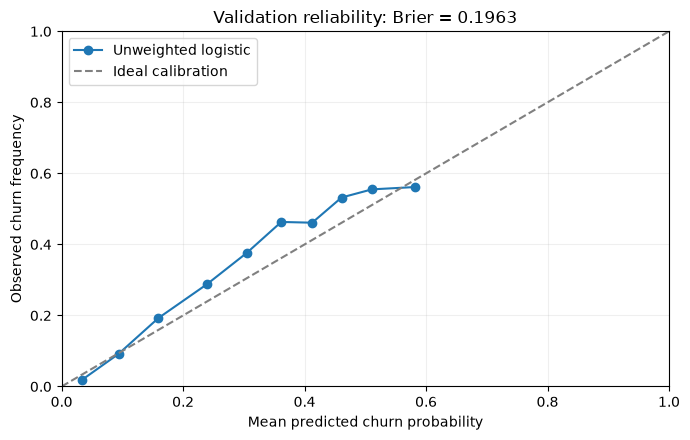

In [11]:
observed_rate, mean_probability = calibration_curve(y_validation, validation_probability,
                                                       n_bins=10, strategy='quantile')
calibration_rows = pd.DataFrame({'probability': validation_probability, 'actual': y_validation.to_numpy()})
calibration_rows['bin'] = pd.qcut(calibration_rows.probability, q=10, duplicates='drop')
calibration_table = (calibration_rows.groupby('bin', observed=True)
    .agg(observations=('actual', 'size'), mean_probability=('probability', 'mean'),
         observed_churn_rate=('actual', 'mean')).reset_index(drop=True))
calibration_table['observed_minus_predicted'] = calibration_table.observed_churn_rate - calibration_table.mean_probability
display(calibration_table)
calibration_table.to_csv(REPORTS / 'logistic_baseline_validation_calibration.csv', index=False)
del calibration_rows
fig, ax = plt.subplots()
ax.plot(mean_probability, observed_rate, 'o-', label='Unweighted logistic')
ax.plot([0, 1], [0, 1], '--', color='grey', label='Ideal calibration')
ax.set(xlabel='Mean predicted churn probability', ylabel='Observed churn frequency',
       title=f'Validation reliability: Brier = {baseline_metrics["brier_score"]:.4f}',
       xlim=(0, 1), ylim=(0, 1))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'logistic_baseline_validation_calibration.png', dpi=160)
plt.show()

## Balanced logistic regression: sensitivity comparison only

The balanced model uses inverse-frequency weights learned from TRAIN. It can shift the effective prior, change the precision/recall trade-off at 0.50 and distort raw probability calibration. Higher recall alone does not make it better. Compare discrimination, top-budget lift and probability error together; retain the unweighted baseline as the default.

,model,roc_auc,average_precision,recall,precision,f1,brier_score,log_loss,lift_at_top10pct,recall_at_top10pct
0,logistic_unweighted,0.729547,0.534197,0.261320,0.547425,0.353765,0.196285,0.565131,1.586844,0.159120
1,logistic_balanced_sensitivity,0.729409,0.534442,0.659767,0.523614,0.583858,0.199816,0.574765,1.599745,0.160414


Balanced minus unweighted: roc_auc: -0.0001; average_precision: +0.0002; lift_at_top10pct: +0.0129; brier_score: +0.0035. Positive Brier change means worse probability error. Small validation differences do not establish robust superiority, especially with repeated players.

,model,mean_predicted_probability,observed_prevalence,mean_prediction_bias,weighted_absolute_bin_gap
0,Unweighted,0.315859,0.353938,-0.038079,0.045647
1,Balanced sensitivity,0.426249,0.353938,0.072311,0.072311


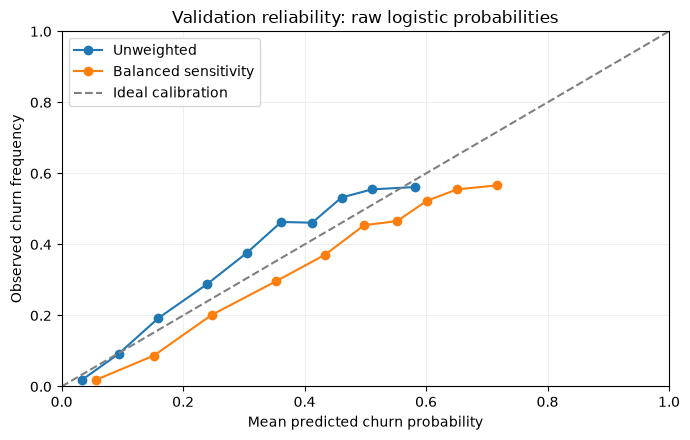

In [12]:
balanced = build_logistic_pipeline(class_weight='balanced')
with warnings.catch_warnings():
    warnings.simplefilter('error', ConvergenceWarning)
    balanced.fit(X_train, y_train)
balanced_probability = balanced.predict_proba(X_validation)[:, 1]
balanced_metrics = {**classification_metrics(y_validation, balanced_probability),
                    **ranking_metrics(y_validation, balanced_probability)}
results = pd.DataFrame([{'model': 'logistic_unweighted', 'split': 'validation', 'threshold': .5,
                         **baseline_metrics},
                       {'model': 'logistic_balanced_sensitivity', 'split': 'validation', 'threshold': .5,
                         **balanced_metrics}])
comparison_columns = ['model', 'roc_auc', 'average_precision', 'recall', 'precision', 'f1',
                      'brier_score', 'log_loss', 'lift_at_top10pct', 'recall_at_top10pct']
display(results[comparison_columns])
display(Markdown('Balanced minus unweighted: ' + '; '.join(
    f'{key}: {balanced_metrics[key] - baseline_metrics[key]:+.4f}'
    for key in ['roc_auc', 'average_precision', 'lift_at_top10pct', 'brier_score']) +
    '. Positive Brier change means worse probability error. Small validation differences '
    'do not establish robust superiority, especially with repeated players.'))

# Descriptive reliability diagnostics only: no calibration fitting.
calibration_comparison_rows = []
fig, ax = plt.subplots()
for name, probabilities in [('Unweighted', validation_probability), ('Balanced sensitivity', balanced_probability)]:
    observed, predicted = calibration_curve(y_validation, probabilities, n_bins=10, strategy='quantile')
    ax.plot(predicted, observed, 'o-', label=name)
    rows = pd.DataFrame({'probability': probabilities, 'actual': y_validation.to_numpy()})
    bins = pd.qcut(rows.probability, q=10, duplicates='drop')
    grouped = rows.groupby(bins, observed=True).agg(
        count=('actual', 'size'), predicted=('probability', 'mean'), observed=('actual', 'mean'))
    calibration_comparison_rows.append({'model': name,
        'mean_predicted_probability': probabilities.mean(),
        'observed_prevalence': y_validation.mean(),
        'mean_prediction_bias': probabilities.mean() - y_validation.mean(),
        'weighted_absolute_bin_gap': np.average((grouped.predicted-grouped.observed).abs(), weights=grouped['count'])})
del rows
calibration_comparison = pd.DataFrame(calibration_comparison_rows)
display(calibration_comparison)
calibration_comparison.to_csv(REPORTS / 'logistic_baseline_validation_calibration_comparison.csv', index=False)
ax.plot([0, 1], [0, 1], '--', color='grey', label='Ideal calibration')
ax.set(xlabel='Mean predicted churn probability', ylabel='Observed churn frequency',
       title='Validation reliability: raw logistic probabilities', xlim=(0, 1), ylim=(0, 1))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'logistic_baseline_validation_calibration_comparison.png', dpi=160)
plt.show()

## Save the baseline and aggregate results

Save the fitted **unweighted TRAIN-only pipeline**, including preprocessing, locally to the Git-ignored `models/` directory. The tracked validation CSV contains metrics only. Nothing is refitted on validation, and the test set remains untouched. The execution metadata makes the artifact's data split and software versions explicit.

In [13]:
joblib.dump(baseline, MODELS / 'logistic_baseline.joblib')
reloaded = joblib.load(MODELS / 'logistic_baseline.joblib')
np.testing.assert_allclose(reloaded.predict_proba(X_validation)[:, 1], validation_probability)
results.to_csv(REPORTS / 'logistic_baseline_validation_metrics.csv', index=False)
execution_metadata = {
    'python_version': sys.version.split()[0], 'pandas_version': pd.__version__,
    'numpy_version': np.__version__, 'sklearn_version': sklearn.__version__,
    'training_snapshots': ['2005-03-31', '2005-12-31'],
    'validation_snapshots': ['2006-03-31', '2006-05-31'],
    'training_observations': len(X_train), 'validation_observations': len(X_validation),
    'test_predictions_generated': False, 'default_model': 'logistic_unweighted',
    'random_state': 42, 'max_iter': 5000,
    'ranking_rounding': 'ceil(n * fraction)', 'ranking_ties': 'stable input order',
    'final_operational_threshold_selected': False,
}
(REPORTS / 'logistic_baseline_run_metadata.json').write_text(
    json.dumps(execution_metadata, indent=2) + '\n', encoding='utf-8')
print('Saved local pipeline and aggregate reports; test predictions generated: False.')

Saved local pipeline and aggregate reports; test predictions generated: False.


## Baseline findings and next-model considerations

The summary below is generated from the executed validation outputs. This preserves the distinction between measured results and assumptions. Validation results guide later model comparison; final generalisation must be assessed once on the sealed test after model selection.

In [14]:
summary_keys = ['roc_auc', 'average_precision', 'precision', 'recall', 'f1', 'brier_score',
                'lift_at_top10pct', 'recall_at_top10pct']
display(results.loc[results.model.eq('logistic_unweighted'), ['model'] + summary_keys].T)

def association_text(table):
    return ', '.join(f'`{row.feature}` ({row.coefficient:+.3f})' for row in table.head(5).itertuples())

mean_prediction = float(validation_probability.mean())
observed_prevalence = float(y_validation.mean())
calibration_gap = mean_prediction - observed_prevalence
largest_bin_gap = float(calibration_table.observed_minus_predicted.abs().max())
balanced_bias = calibration_comparison.iloc[1].mean_prediction_bias
bin_gap_delta = calibration_comparison.iloc[1].weighted_absolute_bin_gap - calibration_comparison.iloc[0].weighted_absolute_bin_gap
missing_top15 = int(missingness.absolute_rank.le(15).sum())
balanced_brier_delta = balanced_metrics['brier_score'] - baseline_metrics['brier_score']
ranking_deltas = {k: balanced_metrics[k] - baseline_metrics[k]
                  for k in ['roc_auc', 'average_precision', 'lift_at_top10pct']}
summary_text = f"""
**Higher-churn associations:** {association_text(positive)}.

**Lower-churn associations:** {association_text(negative)}.

**Numerical associations:** higher churn: {association_text(positive.loc[positive.feature.str.startswith('numeric__')])}; lower churn: {association_text(negative.loc[negative.feature.str.startswith('numeric__')])}. These are conditional on the redundant feature set; individual signs should not be read as standalone behavioural effects.

**Missingness:** {len(missingness)} numerical indicators were learned from TRAIN; {missing_top15} rank in the top 15 absolute coefficients. The table above shows their signs, frequencies and 0-to-1 contrasts. {'Some indicators have comparatively large fitted associations, supporting retention of structural missingness information.' if missing_top15 else 'Indicators are not among the largest standardised associations, but this alone is not grounds for removing them.'} Collinearity and the penalty prevent a causal or standalone importance interpretation.

**Calibration:** mean predicted churn is {mean_prediction:.2%} versus observed {observed_prevalence:.2%} (predicted minus observed: {calibration_gap:+.2%}); this indicates average {'overprediction' if calibration_gap > 0 else 'underprediction'}. The largest absolute quantile-bin gap is {largest_bin_gap:.2%}. Brier score is {baseline_metrics['brier_score']:.4f}, compared with {probability_reference.iloc[0].brier_score:.4f} for the TRAIN-prevalence constant. The reliability table/plot reveals local deviations; bin differences can reflect sampling variation. No calibration has been fitted.

**Balanced sensitivity:** changes versus unweighted are ROC-AUC {ranking_deltas['roc_auc']:+.4f}, AP {ranking_deltas['average_precision']:+.4f}, and Lift@10% {ranking_deltas['lift_at_top10pct']:+.4f}. Ranking {'improves on all three measures' if all(v > 0 for v in ranking_deltas.values()) else 'does not improve consistently across all three measures'}. Brier changes by {balanced_brier_delta:+.4f}, so overall probability error {'worsens' if balanced_brier_delta > 0 else 'improves'}. Balanced mean prediction bias is {balanced_bias:+.2%}, and the weighted absolute quantile-bin gap changes by {bin_gap_delta:+.2%}, indicating {'worse' if bin_gap_delta > 0 else 'better'} calibration by this descriptive bin diagnostic. Bin choice and sampling variation limit this comparison. Keep the unweighted model as the default baseline.

**Before Random Forest / XGBoost:** retain identical temporal boundaries and train-only preprocessing. Review outliers, exact arithmetic redundancy, nested activity windows, rare categories and demographic availability assumptions. Same players can recur across splits, and monthly 60-day outcomes overlap: do not treat observations as independent when constructing future uncertainty intervals. Separate unseen-player generalisation would require another design. Tree models may capture nonlinear patterns but their probability calibration and category handling need validation too. Retention targeting additionally requires intervention benefit and responsible-gambling safeguards; churn prediction does not demonstrate campaign uplift.

No final operational threshold was selected. No test features were transformed and no test probabilities or evaluation metrics were generated. No commit or push is part of this workflow.
"""
display(Markdown(summary_text))

,0
model,logistic_unweighted
roc_auc,0.729547
average_precision,0.534197
precision,0.547425
recall,0.26132
f1,0.353765
brier_score,0.196285
lift_at_top10pct,1.586844
recall_at_top10pct,0.15912



**Higher-churn associations:** `categorical__Language_9` (+1.003), `categorical__Country_792` (+0.736), `categorical__Language_14` (+0.589), `numeric__stake_14d` (+0.565), `categorical__Country_891` (+0.489).

**Lower-churn associations:** `categorical__Language_13` (-1.194), `categorical__Country_616` (-1.150), `categorical__Country_348` (-0.795), `categorical__Language_5` (-0.731), `categorical__Language_7` (-0.701).

**Numerical associations:** higher churn: `numeric__stake_14d` (+0.565), `numeric__days_since_last_active_bet` (+0.486); lower churn: `numeric__active_days_7d` (-0.511), `numeric__bets_14d` (-0.428), `numeric__stake_change_pct_15d` (-0.341). These are conditional on the redundant feature set; individual signs should not be read as standalone behavioural effects.

**Missingness:** 8 numerical indicators were learned from TRAIN; 0 rank in the top 15 absolute coefficients. The table above shows their signs, frequencies and 0-to-1 contrasts. Indicators are not among the largest standardised associations, but this alone is not grounds for removing them. Collinearity and the penalty prevent a causal or standalone importance interpretation.

**Calibration:** mean predicted churn is 31.59% versus observed 35.39% (predicted minus observed: -3.81%); this indicates average underprediction. The largest absolute quantile-bin gap is 10.17%. Brier score is 0.1963, compared with 0.2287 for the TRAIN-prevalence constant. The reliability table/plot reveals local deviations; bin differences can reflect sampling variation. No calibration has been fitted.

**Balanced sensitivity:** changes versus unweighted are ROC-AUC -0.0001, AP +0.0002, and Lift@10% +0.0129. Ranking does not improve consistently across all three measures. Brier changes by +0.0035, so overall probability error worsens. Balanced mean prediction bias is +7.23%, and the weighted absolute quantile-bin gap changes by +2.67%, indicating worse calibration by this descriptive bin diagnostic. Bin choice and sampling variation limit this comparison. Keep the unweighted model as the default baseline.

**Before Random Forest / XGBoost:** retain identical temporal boundaries and train-only preprocessing. Review outliers, exact arithmetic redundancy, nested activity windows, rare categories and demographic availability assumptions. Same players can recur across splits, and monthly 60-day outcomes overlap: do not treat observations as independent when constructing future uncertainty intervals. Separate unseen-player generalisation would require another design. Tree models may capture nonlinear patterns but their probability calibration and category handling need validation too. Retention targeting additionally requires intervention benefit and responsible-gambling safeguards; churn prediction does not demonstrate campaign uplift.

No final operational threshold was selected. No test features were transformed and no test probabilities or evaluation metrics were generated. No commit or push is part of this workflow.
